# Laplace near-field evaluation on the sphere

This notebook studies a **geometry-dependent analytical solution** using a single-layer potential ansatz for a harmonic function. The exact potential is available on the unit sphere, so no numerical reference or BEM solve is needed. The price of this analytical benchmark is that the measured error combines **geometry approximation, density approximation, and numerical quadrature**.

Unlike the jump experiments, where the exact jump relations hold on the discrete surface itself, this benchmark is tied to the exact unit sphere. Both SL and DL operators depend on the integration surface; replacing the sphere by $\Gamma_h$ changes the potential even if integration is exact. **Only SL is evaluated here.** The source mesh and its geometry order must remain fixed during the near-field quadrature comparison. A different geometry or geometry approximation requires a separate experiment and cannot be treated as an interchangeable quadrature setting.


### Description of the experiment

For the unit sphere $\Gamma$, prescribe the density

$$
\rho(\boldsymbol y)=1+\boldsymbol a\cdot\boldsymbol y,
\qquad \boldsymbol a=(0.25,-0.20,0.15).
$$

With the Laplace kernel $G(\boldsymbol x,\boldsymbol y)=$, its single-layer potential is known analytically outside the sphere:

$$
u(\boldsymbol x)=\frac{1}{4\pi}\int\limits_\Gamma \frac{\rho(\boldsymbol y)}{\lVert\boldsymbol x-\boldsymbol y\rVert} \, \mathrm d\sigma_y
=\frac{1}{\|\boldsymbol x\|}+\frac{\boldsymbol a\cdot\boldsymbol x}{3\, \| \boldsymbol x\|^3},
\qquad \textnormal{for}\; \lVert\boldsymbol x\rVert>1.
$$


On the fixed FE mesh $\Gamma_h$, use the smooth extension $\widetilde\rho(\boldsymbol y)=1+\boldsymbol a\cdot\boldsymbol y$ and approximate it by $\rho_h$ in `SurfaceL2`. Select an element-interior anchor $\boldsymbol y_h$ and its outward normal $\boldsymbol n_h$, then evaluate at

$$
\boldsymbol x_\delta=\boldsymbol y_h+\delta\boldsymbol n_h.
$$

The distance sweep approaches the **approximated sphere** along this normal. The offset $\delta$ is not generally the distance to the exact sphere; we also record $\lVert\boldsymbol x_\delta\rVert-1$ and require it to be positive so that the exterior analytical formula applies. The small target screen only supplies evaluation coordinates; it does not discretize the potential solution.

### Error sources

Writing $Q_h\rho_h$ for a numerical potential evaluation at the same physical target, the total error can be decomposed as

$$
Q_h\rho_h-S_\Gamma\rho
=\underbrace{Q_h\rho_h-S_{\Gamma_h}\rho_h}_{\text{quadrature}}
+\underbrace{S_{\Gamma_h}(\rho_h-\widetilde\rho)}_{\text{density approximation}}
+\underbrace{S_{\Gamma_h}\widetilde\rho-S_\Gamma\rho}_{\text{geometry}}.
$$

These are signed contributions and may cancel; the total error alone does not identify their individual sizes.

#### Geometry and density approximation

The default geometry order is 4 and `SurfaceL2` order 2. 

With the trace-space convention `H1` order $p$ and `SurfaceL2` order $p-1$, **geometry order $p+1$ is a practical starting rule** for suppressing geometry error. 
 
Increasing the geometry and FE-space orders can make these errors small, but the rule is not a guarantee for a given mesh or near-field target. The reported radial geometry RMS monitors the surface approximation; it is not a bound on potential error and does not control the largest local surface deviation.

A detailed [interpolation study](../convergence_timing/Interpolation_Convergence_Documentation.ipynb) distinguish interpolation-only errors from combined geometry and interpolation errors.



#### Numerical quadrature

- **Naive Gauss ($G$):** integrates the full near-singular integrand using ordinary Gaussian quadrature.
- **Singularity extraction ($*$):** the built-in ngsbem potential evaluator.

Both paths use effective integration order $q=k+2+b$, where $k$ is the `SurfaceL2` density order and $b$ is `bonus_intorder`. Their integration rules and point counts need not coincide. The main sweep varies $\delta$ and $b$ with fixed geometry and density. 

A quadrature trend in the total error is interpretable **only** while geometry and density errors do not dominate; increasing quadrature order cannot remove those two contributions.

The supplementary density-order sweep retains the original fixed target and varies $k$. Since its bonus is fixed, it also changes $q$ and therefore is not a pure quadrature study.

## Setup and fixed geometry

In [19]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import ngsolve as ngs
import numpy as np
import pandas as pd
from netgen.occ import Axes, OCCGeometry, Sphere, WorkPlane
from ngsolve import BND, CoefficientFunction, GridFunction, Integrate, Mesh, SurfaceL2, TaskManager, ds, sqrt, x, y, z
from ngsolve.bem import LaplaceSL
from ngsolve.fem import IntegrationRule, TRIG


FOUR_PI = 4.0 * np.pi


def as_tuple(values):
    return tuple(float(value) for value in values)


def normalize(values):
    values = np.asarray(values, dtype=float)
    length = float(np.linalg.norm(values))
    if length == 0.0:
        raise ValueError('cannot normalize the zero vector')
    return values / length


def make_sphere_mesh(radius, maxh, curve_order):
    sphere = Sphere((0, 0, 0), radius)
    sphere.faces.name = 'sphere'
    mesh = Mesh(OCCGeometry(sphere).GenerateMesh(maxh=maxh, quad_dominated=False))
    return mesh.Curve(curve_order)


def make_screen_evaluation_mesh(point, normal, size):
    point = np.asarray(point, dtype=float)
    normal = normalize(normal)
    reference = np.array((1.0, 0.0, 0.0))
    if abs(np.dot(reference, normal)) > 0.9:
        reference = np.array((0.0, 1.0, 0.0))
    horizontal = normalize(reference - np.dot(reference, normal) * normal)
    axes = Axes(as_tuple(point), as_tuple(normal), as_tuple(horizontal))
    screen = WorkPlane(axes).RectangleC(2.0 * size, 2.0 * size).Face()
    screen.faces.name = 'target'
    return Mesh(OCCGeometry(screen).GenerateMesh(maxh=size))


def boundary_count(mesh):
    return sum(1 for _ in mesh.Elements(BND))


def geometry_metrics(mesh, radius, integration_order):
    region = mesh.Boundaries('sphere')
    radial_error = sqrt(x * x + y * y + z * z) - radius
    area = Integrate(1, mesh, definedon=region, order=integration_order)
    rms = sqrt(Integrate(radial_error * radial_error, mesh, definedon=region, order=integration_order) / area)
    return float(area), float(rms)


def select_anchor(mesh, direction):
    direction = normalize(direction)
    position_cf = CoefficientFunction((x, y, z))
    normal_cf = ngs.specialcf.normal(3)
    barycenter_rule = IntegrationRule(TRIG, 1)
    candidates = []

    for element in mesh.Elements(BND):
        mapped_point = mesh.GetTrafo(element)(barycenter_rule)
        point = np.asarray(position_cf(mapped_point)[0], dtype=float)
        normal = normalize(normal_cf(mapped_point)[0])
        if np.dot(point, normal) < 0.0:
            normal = -normal
        score = float(np.dot(normalize(point), direction))
        candidates.append((score, element.nr, point, normal))

    _, element_number, point, normal = max(candidates, key=lambda candidate: candidate[0])
    return element_number, point, normal


def as_float(value):
    return float(value.real if hasattr(value, 'real') else value)

In [20]:
radius = 1.0
maxh = 0.5
trace_order = 3  # companion H1 convention; no H1 density is used here
density_order_fixed = trace_order - 1
curve_order = trace_order + 1  # fixed geometry; heuristic, not an error guarantee
density_orders = list(range(7))
bonus_intorder = 0
projection_bonus_intorder = 12
evaluation_distance = 1.0e-4  # target for the supplementary density-order study
distances = [1e-1, 1e-2, 1e-3, evaluation_distance]
quadrature_bonuses = [0, 2, 4, 8, 12, 20]
target_mesh_size = 0.1 * evaluation_distance
target_direction = (-1.0, 0.8, -0.6)
density_vector = np.array((0.25, -0.20, 0.15), dtype=float)
bem_params = {'use_fmm': False}

source_mesh = make_sphere_mesh(radius, maxh, curve_order)
source_region = source_mesh.Boundaries('sphere')
anchor_element, anchor_point, anchor_normal = select_anchor(source_mesh, target_direction)
evaluation_point = as_tuple(anchor_point + evaluation_distance * anchor_normal)

if np.linalg.norm(evaluation_point) <= radius:
    raise RuntimeError('the fixed evaluation point is not exterior to the exact unit sphere')

target_mesh = make_screen_evaluation_mesh(
    evaluation_point, anchor_normal, target_mesh_size
)

r = sqrt(x * x + y * y + z * z)
linear_part = density_vector[0] * x + density_vector[1] * y + density_vector[2] * z
exact_density = 1.0 + linear_part
exact_solution = 1.0 / r + linear_part / (3.0 * r ** 3)
exact_value = as_float(exact_solution(target_mesh(*evaluation_point)))

source_area, source_geom_rms = geometry_metrics(source_mesh, radius, 16)

print(f'source elements: {boundary_count(source_mesh)}')
print(f'source area: {source_area:.12f}')
print(f'source geometry RMS: {source_geom_rms:.3e}')
print(f'anchor element: {anchor_element}')
print(f'anchor point: {as_tuple(anchor_point)}')
print(f'anchor normal: {as_tuple(anchor_normal)}')
print(f'fixed evaluation point: {evaluation_point}')
print(f'target screen elements: {boundary_count(target_mesh)}')
print(f'exact radial distance: {np.linalg.norm(evaluation_point) - radius:.3e}')
print(f'exact value: {exact_value:.12e}')

source elements: 112
source area: 12.566436519682
source geometry RMS: 7.209e-06
anchor element: 81
anchor point: (-0.6861716151556886, 0.6194314087760697, -0.38137923252845835)
anchor normal: (-0.6861724347935257, 0.6194430179123331, -0.38138922020579685)
fixed evaluation point: (-0.686240232399168, 0.6194933530778609, -0.38141737145047894)
target screen elements: 8
exact radial distance: 8.844e-05
exact value: 8.823856428620e-01


### Density projection and potential evaluation

In [21]:
def best_density_approximation(order):
    fes = SurfaceL2(source_mesh, order=order)
    density = GridFunction(fes)
    with TaskManager():
        density.Set(
            exact_density,
            definedon=source_region,
            bonus_intorder=projection_bonus_intorder,
        )

    error_sq = Integrate(
        (density - exact_density) ** 2,
        source_mesh,
        definedon=source_region,
        order=20,
    )
    norm_sq = Integrate(
        exact_density ** 2,
        source_mesh,
        definedon=source_region,
        order=20,
    )
    projection_rel_l2 = float(np.sqrt(error_sq / norm_sq))
    return fes, density, projection_rel_l2


def evaluate_corrected(fes, density, density_order, gauss_order, point=None):
    point = evaluation_point if point is None else point
    bonus = gauss_order - density_order - 2
    if bonus < 0:
        raise ValueError('gauss_order is below the standard potential order')

    trial = fes.TrialFunction()
    start = time.perf_counter()
    with TaskManager():
        solution = LaplaceSL(
            trial * ds(bonus_intorder=bonus),
            **bem_params,
        )(density)
        value = as_float(solution(as_tuple(point)))
    return value, time.perf_counter() - start


def evaluate_naive(density, gauss_order, point=None):
    tx, ty, tz = evaluation_point if point is None else point
    distance = sqrt((tx - x) ** 2 + (ty - y) ** 2 + (tz - z) ** 2)
    integrand = density / (FOUR_PI * distance)

    start = time.perf_counter()
    with TaskManager():
        value = Integrate(
            integrand,
            source_mesh,
            definedon=source_region,
            order=gauss_order,
        )
    return as_float(value), time.perf_counter() - start


def make_row(method, density_order, gauss_order, fes, projection_rel_l2, value, elapsed):
    abs_error = abs(value - exact_value)
    return {
        'method': method,
        'density_order': density_order,
        'gauss_order': gauss_order,
        'bonus_intorder': bonus_intorder,
        'maxh': maxh,
        'curve_order': curve_order,
        'source_elements': boundary_count(source_mesh),
        'fes_ndof': fes.ndof,
        'projection_rel_l2': projection_rel_l2,
        'source_area': source_area,
        'source_geom_rms': source_geom_rms,
        'anchor_element': anchor_element,
        'evaluation_distance': evaluation_distance,
        'target_exact_distance': float(np.linalg.norm(evaluation_point) - radius),
        'target_mesh_size': target_mesh_size,
        'target_x': evaluation_point[0],
        'target_y': evaluation_point[1],
        'target_z': evaluation_point[2],
        'exact_value': exact_value,
        'value': value,
        'abs_error': abs_error,
        'rel_error': abs_error / abs(exact_value),
        'eval_seconds': elapsed,
    }

## Near-field experiment: fixed density and varying distance

In [22]:
# Project once: geometry and density remain fixed throughout this sweep.
fes_fixed, density_fixed, projection_error_fixed = best_density_approximation(density_order_fixed)
distance_rows = []
for delta in distances:
    point = anchor_point + delta * anchor_normal
    radial_distance = float(np.linalg.norm(point) - radius)
    if radial_distance <= 0:
        raise ValueError(f'delta={delta}: target is not exterior to the exact sphere; choose valid exterior offsets')
    radial_norm = float(np.linalg.norm(point))
    exact = 1.0 / radial_norm + float(np.dot(density_vector, point)) / (3.0 * radial_norm**3)
    for bonus in quadrature_bonuses:
        order = density_order_fixed + 2 + bonus
        for method in ('corrected', 'naive_gauss'):
            if method == 'corrected':
                value, elapsed = evaluate_corrected(fes_fixed, density_fixed, density_order_fixed, order, point)
            else:
                value, elapsed = evaluate_naive(density_fixed, order, point)
            distance_rows.append({
                'method': method, 'delta': delta, 'target_exact_distance': radial_distance,
                'density_order': density_order_fixed, 'curve_order': curve_order,
                'maxh': maxh, 'bonus_intorder': bonus, 'gauss_order': order,
                'projection_rel_l2': projection_error_fixed, 'source_geom_rms': source_geom_rms,
                'target_x': point[0], 'target_y': point[1], 'target_z': point[2],
                'value': value, 'exact_value': exact,
                'rel_error': abs(value-exact) / abs(exact), 'eval_seconds': elapsed,
            })
distance_results = pd.DataFrame(distance_rows)
display(distance_results)
print(f'Fixed density: SurfaceL2 order {density_order_fixed}; relative L2 projection error = {projection_error_fixed:.3e}')


,method,delta,target_exact_distance,density_order,curve_order,maxh,bonus_intorder,gauss_order,projection_rel_l2,source_geom_rms,target_x,target_y,target_z,value,exact_value,rel_error,eval_seconds
0,corrected,0.1000,0.099988,2,4,0.5,0,4,0.000435,0.000007,-0.754789,0.681376,-0.419518,0.811949,0.811952,0.000005,0.024596
1,naive_gauss,0.1000,0.099988,2,4,0.5,0,4,0.000435,0.000007,-0.754789,0.681376,-0.419518,0.811710,0.811952,0.000299,0.035785
2,corrected,0.1000,0.099988,2,4,0.5,2,6,0.000435,0.000007,-0.754789,0.681376,-0.419518,0.811959,0.811952,0.000009,0.040160
3,naive_gauss,0.1000,0.099988,2,4,0.5,2,6,0.000435,0.000007,-0.754789,0.681376,-0.419518,0.811689,0.811952,0.000324,0.042863
4,corrected,0.1000,0.099988,2,4,0.5,4,8,0.000435,0.000007,-0.754789,0.681376,-0.419518,0.811965,0.811952,0.000015,0.012206
5,naive_gauss,0.1000,0.099988,2,4,0.5,4,8,0.000435,0.000007,-0.754789,0.681376,-0.419518,0.811965,0.811952,0.000015,0.017086
6,corrected,0.1000,0.099988,2,4,0.5,8,12,0.000435,0.000007,-0.754789,0.681376,-0.419518,0.811964,0.811952,0.000014,0.015387
7,naive_gauss,0.1000,0.099988,2,4,0.5,8,12,0.000435,0.000007,-0.754789,0.681376,-0.419518,0.811956,0.811952,0.000004,0.015463
8,corrected,0.1000,0.099988,2,4,0.5,12,16,0.000435,0.000007,-0.754789,0.681376,-0.419518,0.811964,0.811952,0.000014,0.013768
9,naive_gauss,0.1000,0.099988,2,4,0.5,12,16,0.000435,0.000007,-0.754789,0.681376,-0.419518,0.811964,0.811952,0.000014,0.024784


Fixed density: SurfaceL2 order 2; relative L2 projection error = 4.354e-04


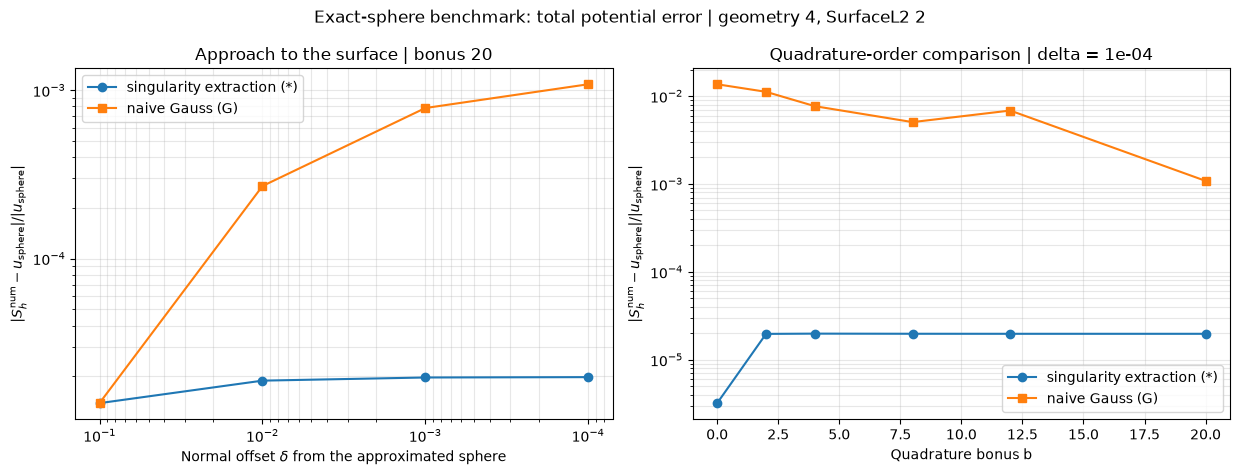

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
selected_bonus = max(quadrature_bonuses)
closest_delta = min(distances)
for method, label, marker in (
    ('corrected', 'singularity extraction (*)', 'o'),
    ('naive_gauss', 'naive Gauss (G)', 's'),
):
    data = distance_results[(distance_results.method == method) & (distance_results.bonus_intorder == selected_bonus)].sort_values('delta')
    axes[0].loglog(data.delta, data.rel_error, marker=marker, label=label)
    data = distance_results[(distance_results.method == method) & (distance_results.delta == closest_delta)].sort_values('bonus_intorder')
    axes[1].semilogy(data.bonus_intorder, data.rel_error, marker=marker, label=label)
axes[0].set_xlabel(r'Normal offset $\delta$ from the approximated sphere')
axes[0].set_title(f'Approach to the surface | bonus {selected_bonus}')
axes[0].invert_xaxis()
axes[1].set_xlabel('Quadrature bonus b')
axes[1].set_title(f'Quadrature-order comparison | delta = {closest_delta:.0e}')
for ax in axes:
    ax.set_ylabel(r'$|S_h^{\mathrm{num}}-u_{\mathrm{sphere}}|/|u_{\mathrm{sphere}}|$')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()
fig.suptitle(f'Exact-sphere benchmark: total potential error | geometry {curve_order}, SurfaceL2 {density_order_fixed}')
fig.tight_layout()
output_dir = Path('output')
output_dir.mkdir(exist_ok=True)
fig.savefig(output_dir / 'laplace_exact_sphere_nearfield.png', dpi=300)
plt.show()
distance_results.to_csv(output_dir / 'laplace_exact_sphere_distance_results.csv', index=False)


## Supplementary density-order study at a fixed target

In [24]:
rows = []

for density_order in density_orders:
    fes, density, projection_rel_l2 = best_density_approximation(density_order)
    gauss_order = density_order + 2 + bonus_intorder

    corrected_value, corrected_seconds = evaluate_corrected(
        fes, density, density_order, gauss_order
    )
    naive_value, naive_seconds = evaluate_naive(density, gauss_order)

    rows.append(
        make_row(
            'corrected',
            density_order,
            gauss_order,
            fes,
            projection_rel_l2,
            corrected_value,
            corrected_seconds,
        )
    )
    rows.append(
        make_row(
            'naive_gauss',
            density_order,
            gauss_order,
            fes,
            projection_rel_l2,
            naive_value,
            naive_seconds,
        )
    )

    print(
        f'p={density_order}, q={gauss_order}: '
        f'projection={projection_rel_l2:.3e}, '
        f'corrected={rows[-2]["rel_error"]:.3e}, '
        f'naive={rows[-1]["rel_error"]:.3e}'
    )

results = pd.DataFrame(rows)
results

p=0, q=2: projection=4.419e-02, corrected=3.164e-02, naive=4.465e-02
p=1, q=3: projection=4.266e-03, corrected=1.643e-03, naive=1.169e-02
p=2, q=4: projection=4.354e-04, corrected=3.215e-06, naive=1.360e-02
p=3, q=5: projection=2.218e-05, corrected=1.831e-05, naive=1.118e-02
p=4, q=6: projection=2.188e-06, corrected=8.868e-07, naive=1.118e-02
p=5, q=7: projection=9.314e-08, corrected=9.403e-07, naive=1.036e-02
p=6, q=8: projection=1.198e-08, corrected=8.230e-07, naive=7.682e-03


,method,density_order,gauss_order,bonus_intorder,maxh,curve_order,source_elements,fes_ndof,projection_rel_l2,source_area,...,target_exact_distance,target_mesh_size,target_x,target_y,target_z,exact_value,value,abs_error,rel_error,eval_seconds
0,corrected,0,2,0,0.5,4,112,112,4.419027e-02,12.566437,...,0.000088,0.00001,-0.68624,0.619493,-0.381417,0.882386,0.854467,2.791833e-02,3.163960e-02,0.000992
1,naive_gauss,0,2,0,0.5,4,112,112,4.419027e-02,12.566437,...,0.000088,0.00001,-0.68624,0.619493,-0.381417,0.882386,0.842988,3.939785e-02,4.464924e-02,0.004295
2,corrected,1,3,0,0.5,4,112,336,4.266408e-03,12.566437,...,0.000088,0.00001,-0.68624,0.619493,-0.381417,0.882386,0.883836,1.449999e-03,1.643272e-03,0.011060
3,naive_gauss,1,3,0,0.5,4,112,336,4.266408e-03,12.566437,...,0.000088,0.00001,-0.68624,0.619493,-0.381417,0.882386,0.872067,1.031818e-02,1.169350e-02,0.005295
4,corrected,2,4,0,0.5,4,112,672,4.353710e-04,12.566437,...,0.000088,0.00001,-0.68624,0.619493,-0.381417,0.882386,0.882383,2.837003e-06,3.215151e-06,0.011392
5,naive_gauss,2,4,0,0.5,4,112,672,4.353710e-04,12.566437,...,0.000088,0.00001,-0.68624,0.619493,-0.381417,0.882386,0.870381,1.200420e-02,1.360425e-02,0.017633
6,corrected,3,5,0,0.5,4,112,1120,2.217990e-05,12.566437,...,0.000088,0.00001,-0.68624,0.619493,-0.381417,0.882386,0.882369,1.615745e-05,1.831110e-05,0.005519
7,naive_gauss,3,5,0,0.5,4,112,1120,2.217990e-05,12.566437,...,0.000088,0.00001,-0.68624,0.619493,-0.381417,0.882386,0.872520,9.865292e-03,1.118025e-02,0.004890
8,corrected,4,6,0,0.5,4,112,1680,2.188024e-06,12.566437,...,0.000088,0.00001,-0.68624,0.619493,-0.381417,0.882386,0.882385,7.824575e-07,8.867524e-07,0.013699
9,naive_gauss,4,6,0,0.5,4,112,1680,2.188024e-06,12.566437,...,0.000088,0.00001,-0.68624,0.619493,-0.381417,0.882386,0.872520,9.865450e-03,1.118043e-02,0.020195


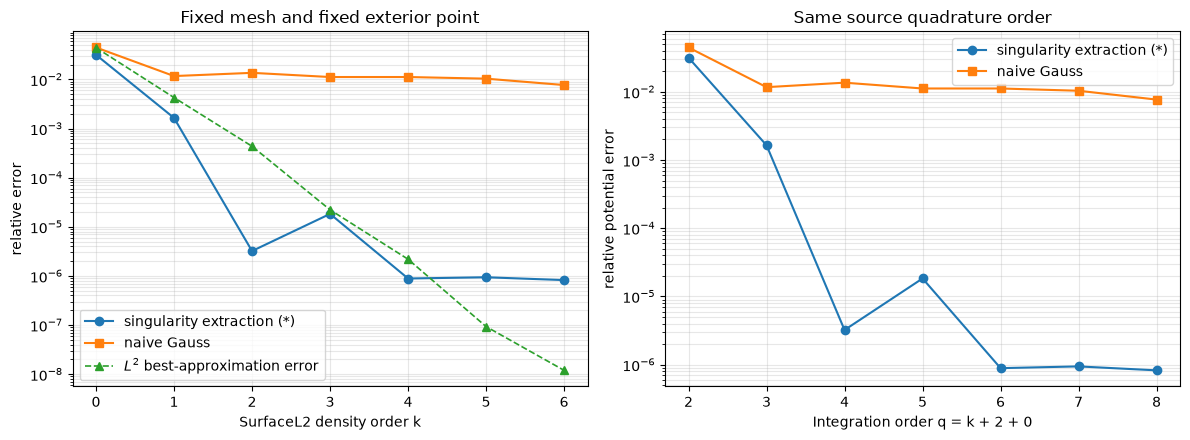

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for method, label, marker in (
    ('corrected', 'singularity extraction (*)', 'o'),
    ('naive_gauss', 'naive Gauss', 's'),
):
    data = results[results['method'] == method]
    axes[0].semilogy(
        data['density_order'],
        data['rel_error'],
        marker=marker,
        linewidth=1.5,
        label=label,
    )
    axes[1].semilogy(
        data['gauss_order'],
        data['rel_error'],
        marker=marker,
        linewidth=1.5,
        label=label,
    )

projection = results[results['method'] == 'corrected']
axes[0].semilogy(
    projection['density_order'],
    projection['projection_rel_l2'],
    marker='^',
    linestyle='--',
    linewidth=1.2,
    label=r'$L^2$ best-approximation error',
)

axes[0].set_xlabel('SurfaceL2 density order k')
axes[0].set_ylabel('relative error')
axes[0].set_title('Fixed mesh and fixed exterior point')
axes[1].set_xlabel(f'Integration order q = k + 2 + {bonus_intorder}')
axes[1].set_ylabel('relative potential error')
axes[1].set_title('Same source quadrature order')

for axis in axes:
    axis.grid(True, which='both', alpha=0.3)
    axis.legend()

fig.tight_layout()
plt.show()

The supplementary sweep changes the density order and, through `q = k + 2 + bonus`, also the integration order. Geometry, source elements, and the physical target remain fixed. The density projection error helps identify approximation trends, but cannot be read as a pointwise potential-error bound. A potential-error plateau may contain both geometry and quadrature contributions; it cannot be attributed from this plot alone.


In [ ]:
results.to_csv(output_dir / 'laplace_exact_sphere_nearfield_quadrature.csv', index=False)
print(f'wrote {output_dir / "laplace_exact_sphere_nearfield_quadrature.csv"}')

wrote /home/lw/ngsuite/ngsolve-src/docs/docu-ngsbem/nearfield/output/laplace_exact_sphere_nearfield_quadrature.csv


## Reading the results

The main distance and order plots show the **total relative error against the analytical sphere potential**, not an isolated quadrature error. There is no boundary-limit truncation error in this comparison: the analytical formula is evaluated at each actual target point. Changing the offset changes the evaluation point and the difficulty of integration, while the source geometry and projected density stay fixed.

The advantage is an analytical benchmark for the potential values themselves, independent of a BEM solve or high-order numerical reference. The limitation is its dependence on the sphere: geometry and density approximation contribute to every value comparison. The jump notebooks avoid these approximation errors by testing exact relations on the discrete surface; this notebook deliberately tests the full approximation to a sphere potential.

A reduction with increasing quadrature bonus indicates sensitivity to integration. A plateau is not sufficient evidence of a quadrature failure or success: it may be set by geometry or density approximation, and signed error contributions can cancel. Compare the projection diagnostic and the geometry RMS, and use separate geometry/density refinement studies before assigning the plateau to a single source. High geometry order helps expose quadrature behavior only if density approximation is also sufficiently accurate.

The current distance range approaches the approximated sphere from outside and checks that every target is also outside the exact sphere. Smaller offsets can be added only while that condition holds; $\delta$ and the exact radial distance should not be confused. The geometry RMS alone cannot establish this condition locally.


### Observation for the default configuration

At the closest target ($\delta=3\cdot10^{-4}$), singularity extraction reaches a total relative error of approximately $2\cdot10^{-5}$ from bonus 2 onward. The smaller total error at bonus 0 is not evidence of more accurate integration: it is consistent with cancellation between quadrature and approximation contributions. This experiment does not separately quantify those contributions to the potential error.

The reported density projection error is approximately $4.4\cdot10^{-4}$ in relative $L^2$, and the radial geometry RMS is approximately $7\cdot10^{-6}$. These diagnostics have different meanings and cannot be compared directly with the relative potential error to decide which contribution dominates. The exact radial target distance differs from the prescribed normal offset by approximately $1.2\cdot10^{-5}$, illustrating why the exterior check matters. These observations refer to the default run; the tables and plots are recomputed when parameters change.
